<a href="https://colab.research.google.com/github/joshho0701/everyone-can-use-english/blob/main/predictor_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Environment Set-up
edit from [sam colab](https://colab.research.google.com/github/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb#scrollTo=MTeAdX_mHwAR)



If you're running this notebook locally using Jupyter, please clone `SAM-Med2D` into a directory named `SAM_Med2D`. Note that you do **not** need to install `segment_anything` in your local environment, as `SAM-Med2D` and `SAM` share function names that could lead to conflicts.

For Google Colab users: Set `using_colab=True` in the cell below before executing it. Although you can select 'GPU' under 'Edit' -> 'Notebook Settings' -> 'Hardware Accelerator', this notebook is designed to run efficiently in a CPU environment as well.



In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("praveengovi/coronahack-chest-xraydataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'coronahack-chest-xraydataset' dataset.
Path to dataset files: /kaggle/input/coronahack-chest-xraydataset


In [2]:
using_colab = True

In [3]:
!git clone https://github.com/OpenGVLab/SAM-Med2D.git SAM_Med2D
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    # !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

    # !mkdir images
    # !wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg

else:
    # not sure for this part! Please check!
    !pip install torch==1.11.0+cu113 torchvision==0.12.0+cu113 -f https://download.pytorch.org/whl/torch_stable.html
    !pip install opencv-python matplotlib
    # !pip install 'git+https://github.com/facebookresearch/segment-anything.git'

fatal: destination path 'SAM_Med2D' already exists and is not an empty directory.
PyTorch version: 2.9.0+cu126
Torchvision version: 0.24.0+cu126
CUDA is available: True


# Download Weight
edit from [samed colab](https://colab.research.google.com/drive/1KCS5ulpZasYl9DgJJn59WsGEB8vwSI_m?usp=sharing#scrollTo=NI9jWQnsPty2)

In [4]:
import os
import gdown


ROOT_DIR = '.'
CODE_DIR = f"{ROOT_DIR}/SAM_Med2D"
MODEL_DIR = f"{CODE_DIR}/pretrain_model"
os.makedirs(MODEL_DIR, exist_ok=True)


file_id = '1ARiB5RkSsWmAB_8mqWnwDF8ZKTtFwsjl'
file_name = 'sam-med2d_b.pth'
output_path = f'{MODEL_DIR}/{file_name}'

if not os.path.exists(output_path):
    print(f" {file_name} ...")
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url, output_path, quiet=False)
else:
    print(f' {file_name} ')

 sam-med2d_b.pth 


In [5]:
import kagglehub


dataset_path = kagglehub.dataset_download("praveengovi/coronahack-chest-xraydataset")

print(f"您的 X-Ray 資料集路徑在: {dataset_path}")

# 2. 設定資料集變數 (這通常是下一步訓練程式會用到的變數名稱)
# 假設您的訓練程式需要一個 'data_root'
data_root = dataset_path

Using Colab cache for faster access to the 'coronahack-chest-xraydataset' dataset.
您的 X-Ray 資料集路徑在: /kaggle/input/coronahack-chest-xraydataset


# SAM-Med2D generates predicted object masks based on prompts.

In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
import sys
sys.path.append(ROOT_DIR) # make sure the import SAM_Med2D.segment_anything work

In [7]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))


## Example image

In [8]:
os.chdir(f'{CODE_DIR}')
image = cv2.imread('data_demo/images/amos_0507_31.png')
image.shape

(290, 320, 3)

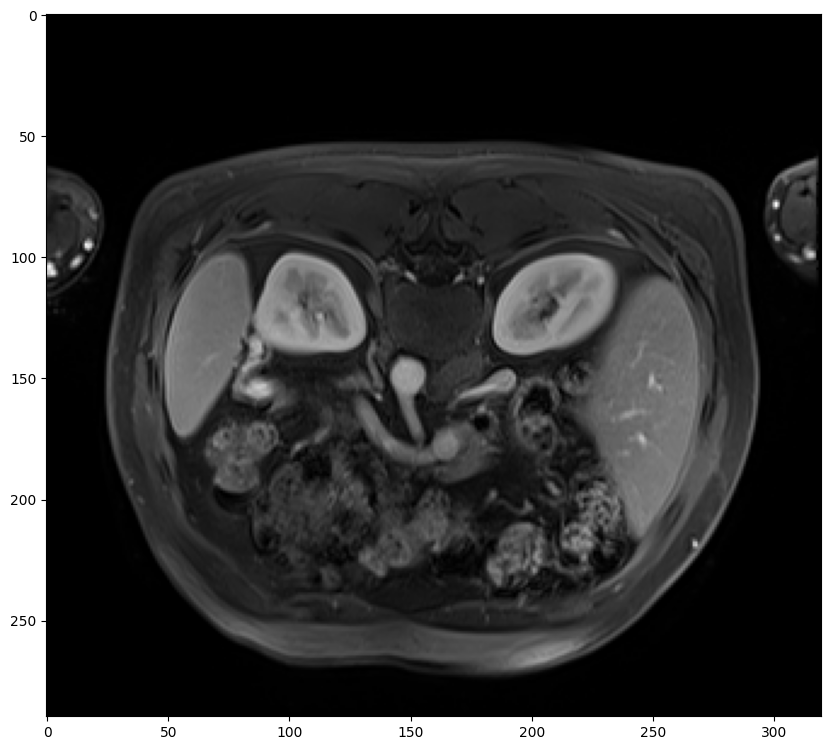

In [9]:
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.show()

## Load SAM-Med2D model

In [10]:
import os
import torch
import gdown
from argparse import Namespace
from SAM_Med2D.segment_anything import sam_model_registry
from SAM_Med2D.segment_anything.predictor_sammed import SammedPredictor


model_folder = "SAM_Med2D/pretrain_model"
os.makedirs(model_folder, exist_ok=True)

ckpt_path = os.path.join(model_folder, "sam-med2d_b.pth")

if not os.path.exists(ckpt_path):
    print(f"找不到檔案：{ckpt_path}")
    print("重新下載模型，請稍候...")
    file_id = '1ARiB5RkSsWmAB_8mqWnwDF8ZKTtFwsjl'
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url, ckpt_path, quiet=False)
else:
    print(f"模型檔案存在 ({ckpt_path})")

_original_torch_load = torch.load
def patched_torch_load(*args, **kwargs):

    if 'weights_only' not in kwargs:
        kwargs['weights_only'] = False
    return _original_torch_load(*args, **kwargs)

torch.load = patched_torch_load



args = Namespace()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args.image_size = 256
args.encoder_adapter = True
args.sam_checkpoint = ckpt_path  # 使用我們剛剛確認過的路徑

try:
    model = sam_model_registry["vit_b"](args).to(device)
    predictor = SammedPredictor(model)

except Exception as e:
    print(f"錯誤：{e}")

模型檔案存在 (SAM_Med2D/pretrain_model/sam-med2d_b.pth)
True
*******load SAM_Med2D/pretrain_model/sam-med2d_b.pth


Using Colab cache for faster access to the 'coronahack-chest-xraydataset' dataset.
📄 讀取圖片: person1676_virus_2892.jpeg
正在設定圖片給 SAM 模型...
圖片已設定，現在可以進行分割預測了。


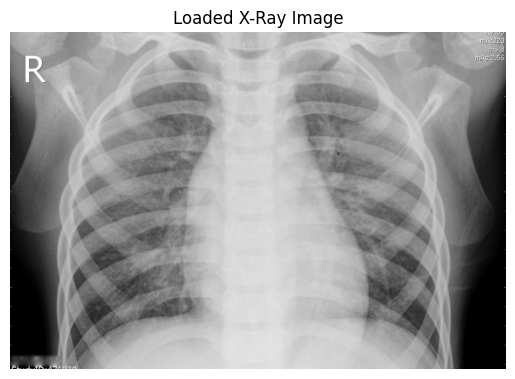

In [11]:
import os
import cv2
import torch
import glob
import matplotlib.pyplot as plt
import numpy as np
from argparse import Namespace
from SAM_Med2D.segment_anything import sam_model_registry
from SAM_Med2D.segment_anything.predictor_sammed import SammedPredictor


_original_torch_load = torch.load
def patched_torch_load(*args, **kwargs):
    if 'weights_only' not in kwargs: kwargs['weights_only'] = False
    return _original_torch_load(*args, **kwargs)
torch.load = patched_torch_load

if 'predictor' not in locals():
    print("重新載入模型...")
    ckpt_path = "SAM_Med2D/pretrain_model/sam-med2d_b.pth"


    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"找不到模型檔案：{ckpt_path}，請先執行上一格下載程式碼！")

    args = Namespace()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    args.image_size = 256
    args.encoder_adapter = True
    args.sam_checkpoint = ckpt_path

    model = sam_model_registry["vit_b"](args).to(device)
    predictor = SammedPredictor(model)


import kagglehub

dataset_path = kagglehub.dataset_download("praveengovi/coronahack-chest-xraydataset")

search_path = os.path.join(dataset_path, "**", "*.jpeg")
image_files = glob.glob(search_path, recursive=True)

if len(image_files) > 0:
    image_path = image_files[0] # 拿第一張圖來做測試
    print(f"讀取圖片: {os.path.basename(image_path)}")


    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # 轉成 RGB


    print("正在設定圖片給 SAM 模型...")
    predictor.set_image(image)
    print("圖片已設定，現在可以進行分割預測了。")

    plt.imshow(image)
    plt.title("Loaded X-Ray Image")
    plt.axis('off')
    plt.show()

else:
    print("錯誤：在資料集路徑中找不到任何 .jpeg 圖片，請檢查資料集是否下載成功。")

這裡搜尋圖片: /kaggle/input/coronahack-chest-xraydataset
找到 X-Ray 圖片：person1676_virus_2892.jpeg
檔案大小：174.92 KB


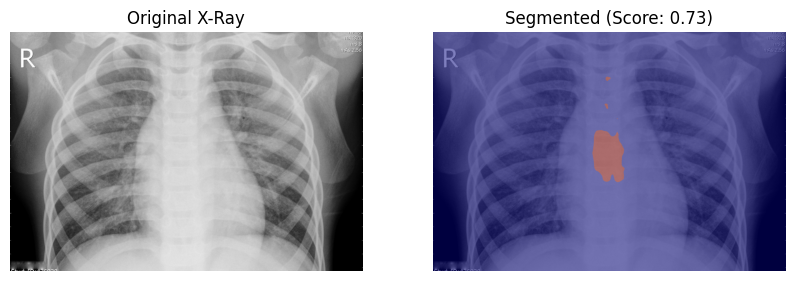

In [13]:
import glob


if 'dataset_path' not in locals():
    dataset_path = "/root/.cache/kagglehub/datasets/praveengovi/coronahack-chest-xraydataset/versions/3"

print(f"這裡搜尋圖片: {dataset_path}")

# 2. 抓取所有圖片 (包含 .jpeg 和 .jpg)
image_files = glob.glob(os.path.join(dataset_path, "**", "*.jpeg"), recursive=True)
image_files += glob.glob(os.path.join(dataset_path, "**", "*.jpg"), recursive=True)


valid_xrays = []


for img_path in image_files:
    try:
        file_size = os.path.getsize(img_path)
        # 過濾邏輯：只有大於 50KB (51200 bytes) 的才算是 X 光片
        if file_size > 51200:
            valid_xrays.append(img_path)
    except:
        continue


if valid_xrays:

    target_image_path = valid_xrays[0]
    print(f"找到 X-Ray 圖片：{os.path.basename(target_image_path)}")
    print(f"檔案大小：{os.path.getsize(target_image_path)/1024:.2f} KB")


    image = cv2.imread(target_image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


    predictor.set_image(image)

    input_point = np.array([[image.shape[1]//2, image.shape[0]//2]])


    masks, scores, logits = predictor.predict(
        point_coords=input_point,
        point_labels=np.array([1]),
        multimask_output=True,
    )


    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("Original X-Ray")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(image)
    # 顯示分數最高的遮罩
    best_idx = np.argmax(scores)
    plt.imshow(masks[best_idx], alpha=0.5, cmap='jet')
    plt.title(f"Segmented (Score: {scores[best_idx]:.2f})")
    plt.axis('off')
    plt.show()




Process the image to produce an image embedding by calling `SammedPredictor.set_image`. `SammedPredictor` remembers this embedding and will use it for subsequent mask prediction.

In [15]:
predictor.set_image(image)

## Specifying a specific object with a point

In [16]:
ori_h, ori_w, _ = image.shape
input_point = np.array([[162, 127]])
input_label = np.array([1])

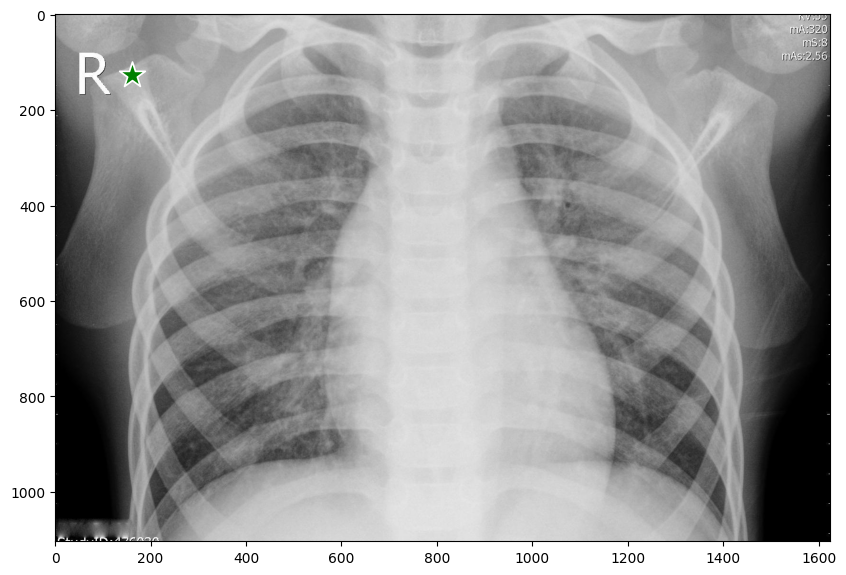

In [17]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()

In [18]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)
masks.shape  # (number_of_masks) x H x W

(1, 1104, 1624)

Predict with `SammedPredictor.predict`. The model returns masks, quality predictions for those masks, and low resolution mask logits that can be passed to the next iteration of prediction.

With `multimask_output=True` (the default setting), SAM outputs 3 masks, where `scores` gives the model's own estimation of the quality of these masks. This setting is intended for ambiguous input prompts, and helps the model disambiguate different objects consistent with the prompt. When `False`, it will return a single mask. For ambiguous prompts such as a single point, it is recommended to use `multimask_output=True` even if only a single mask is desired; the best single mask can be chosen by picking the one with the highest score returned in `scores`. This will often result in a better mask.

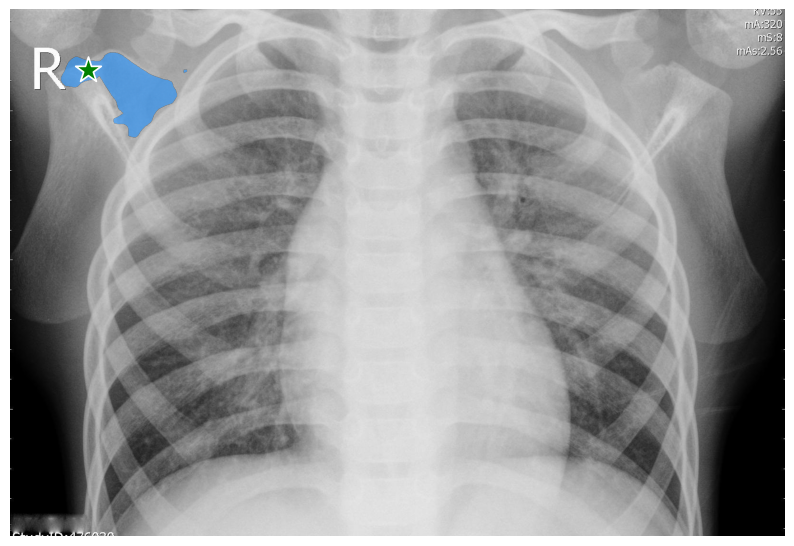

In [19]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_mask(masks, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()


## Optimizing Segmentation Results by Point Interaction

In [20]:
input_point1 = np.array([[169, 140]])
input_label1 = np.array([0])
input_points = np.concatenate((input_point, input_point1))
input_labels = np.concatenate((input_label, input_label1))
mask_inputs = torch.sigmoid(torch.as_tensor(logits, dtype=torch.float, device=device))

In [21]:
masks, scores, logits = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    mask_input = mask_inputs,
    multimask_output=True,
)
masks.shape  # (number_of_masks) x H x W

(1, 1104, 1624)

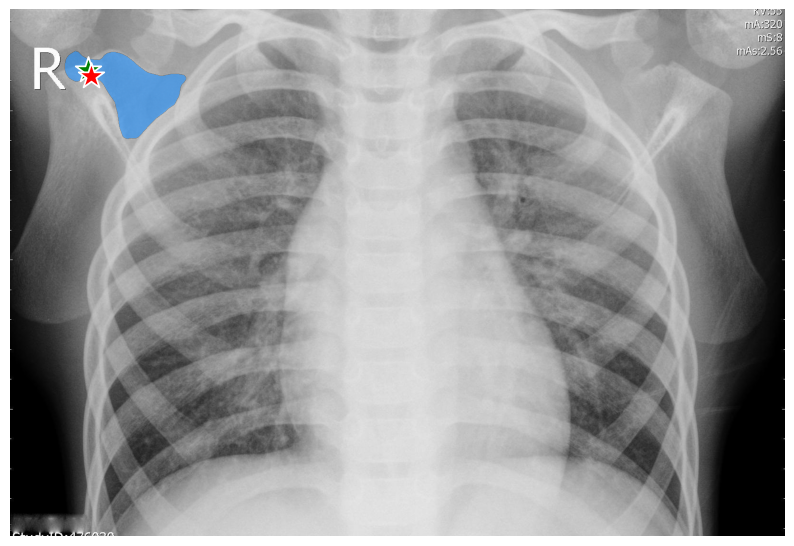

In [22]:

plt.figure(figsize=(10,10))
plt.imshow(image)
show_mask(masks, plt.gca())
show_points(input_points, input_labels, plt.gca())
plt.axis('off')
plt.show()

## Specifying a specific object with a bounding box

The model can also take a box as input, provided in xyxy format.

In [23]:
image = cv2.imread('data_demo/images/s0114_111.png')
predictor.set_image(image)
input_box = np.array([89,43,113,64]) #

In [24]:
masks, _, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box,
    multimask_output=True,
)

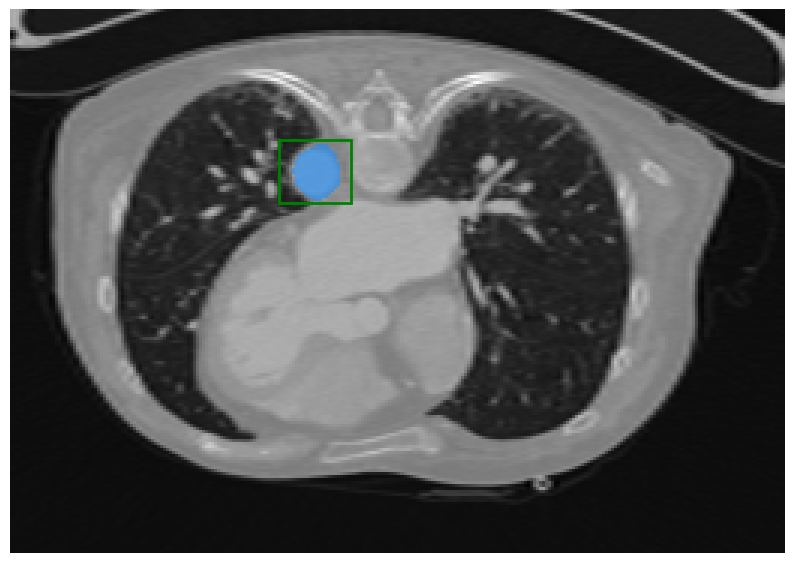

In [25]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks[0], plt.gca())
show_box(input_box, plt.gca())
plt.axis('off')
plt.show()

## Multiple bounding box prediction results

In [26]:
input_boxes = torch.tensor([[72,110,136,143],[124,92,160,132]], device=predictor.device)

In [27]:
transformed_boxes = predictor.apply_boxes_torch(input_boxes, image.shape[:2], (args.image_size, args.image_size))
masks, _, _ = predictor.predict_torch(
    point_coords=None,
    point_labels=None,
    boxes=transformed_boxes,
    multimask_output=True,
)
print(transformed_boxes.shape)
print(masks.shape)  # (batch_size) x (num_predicted_masks_per_input) x H x W

torch.Size([2, 4])
torch.Size([2, 1, 181, 258])


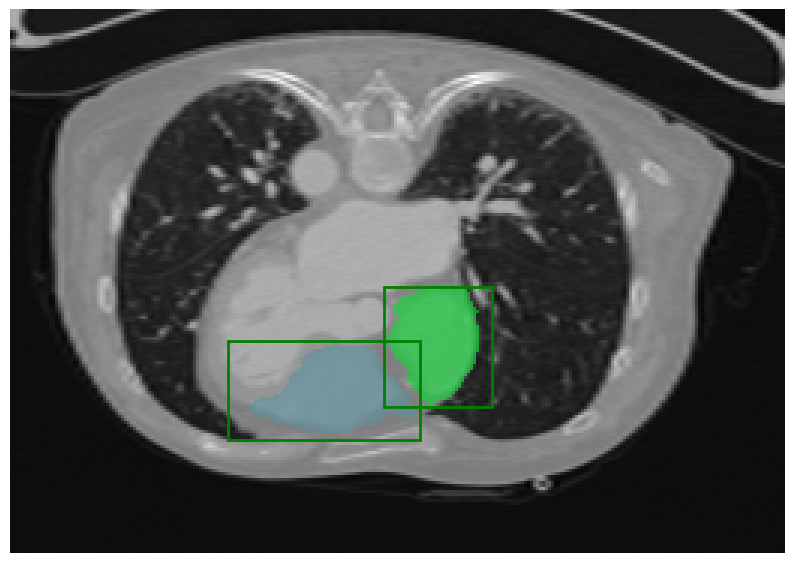

In [28]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
for mask in masks:
    show_mask(mask.cpu().numpy(), plt.gca(), random_color=True)
for box in input_boxes:
    show_box(box.cpu().numpy(), plt.gca())
plt.axis('off')
plt.show()

